# Step by Step Fact Checking 

This code runs a step-by-step Fact Checking pipeline 

In [ ]:
import sys

sys.path.append("..")

In [ ]:
from dotenv import load_dotenv

load_dotenv(".env")

In [ ]:
import json
from textwrap import wrap

from IPython.display import HTML, display

from veridika.src.workflows.StepwiseWorkflows import (
    CrititalQuestionRefinementWorkflow,
    CrititalQuestionWorkflow,
    FactCheckingWorkflow,
    GenSearchesWorkflow,
    ImageGenerationWorkflow,
    SourceRefinementWorkflow,
)

In [5]:
statement = "Los coches eléctricos son más contaminantes que los coches de gasolina"
language = "es"
location = "es"

## Critical questions generation

In [6]:
critical_question_workflow = CrititalQuestionWorkflow()
critical_questions, cost = await critical_question_workflow.run(
    statement=statement,
    language=language,
    location=location,
    model="Latxa70B",
)
print(json.dumps(critical_questions, indent=4, ensure_ascii=False))
print(f"💰 Step cost: {cost}")

{
    "questions": [
        "¿Cuáles son las emisiones de gases de efecto invernadero y otros contaminantes de los coches eléctricos y de gasolina según la Agencia Internacional de Energía?",
        "¿Cómo se compara el impacto ambiental del ciclo de vida de los coches eléctricos y de gasolina?",
        "¿Cuál es la composición de la matriz energética en diferentes regiones y países y cómo afecta a la huella de carbono de los coches eléctricos?",
        "¿Cuáles son las emisiones reales de coches eléctricos y de gasolina en diferentes condiciones de conducción y climáticas?",
        "¿Qué dicen los expertos en energía y medio ambiente sobre la comparación de la contaminación de coches eléctricos y de gasolina?",
        "¿Cuáles son los últimos avances tecnológicos y cambios en la regulación que afectan la comparación de la contaminación entre coches eléctricos y de gasolina en 2025?"
    ]
}
💰 Step cost: 0.0


#### Critical question refinement

In [7]:
critial_question_refinement_workflow = CrititalQuestionRefinementWorkflow()
refinement = "También quiero que consideres la contaminación del proceso de reciclaje de la batería"
new_critical_questions, cost = await critial_question_refinement_workflow.run(
    questions=critical_questions["questions"],
    input=statement,
    refinement=refinement,
    language=language,
    location=location,
    model="Latxa70B",
)
print(json.dumps(new_critical_questions, indent=4, ensure_ascii=False))
print(f"💰 Step cost: {cost}")

{
    "questions": [
        "¿Cuáles son las emisiones de gases de efecto invernadero y otros contaminantes de los coches eléctricos y de gasolina según la Agencia Internacional de Energía?",
        "¿Cómo se compara el impacto ambiental del ciclo de vida de los coches eléctricos y de gasolina?",
        "¿Cuál es la composición de la matriz energética en diferentes regiones y países y cómo afecta a la huella de carbono de los coches eléctricos?",
        "¿Cuáles son las emisiones reales de coches eléctricos y de gasolina en diferentes condiciones de conducción y climáticas?",
        "¿Qué dicen los expertos en energía y medio ambiente sobre la comparación de la contaminación de coches eléctricos y de gasolina?",
        "¿Cuáles son los últimos avances tecnológicos y cambios en la regulación que afectan la comparación de la contaminación entre coches eléctricos y de gasolina en 2025?",
        "¿Cuál es el impacto ambiental del proceso de reciclaje de baterías de coches eléctricos

# Web Search

In [8]:
gen_searches_workflow = GenSearchesWorkflow()
sources, searches, cost = await gen_searches_workflow.run(
    statement=statement,
    questions=new_critical_questions["questions"],
    language=language,
    location=location,
    model="Latxa70B",
)


def display_sources(sources):
    for element in sources:
        link = element["link"]
        snippet = element["snippet"]
        favicon = element["favicon"]
        title = element["title"]

        # Create HTML with embedded favicon image
        favicon_html = (
            f'<img src="{favicon}" width="16" height="16" style="vertical-align: middle; margin-right: 5px;">'
            if favicon
            else "🌐"
        )

        html_output = f"""
        <div style="border: 1px solid #ddd; padding: 15px; margin: 10px 0; border-radius: 5px; background-color: #f9f9f9;">
            <div style="font-weight: bold; font-size: 16px; margin-bottom: 10px;">
                {favicon_html} {title}
            </div>
            <div style="color: #1a0dab; margin-bottom: 8px; word-wrap: break-word;">
                🔗 <a href="{link}" target="_blank">{link if link else "N/A"}</a>
            </div>
            <div style="color: #545454; line-height: 1.5;">
                {snippet}
            </div>
        </div>
        """

        display(HTML(html_output))


for search in searches:
    print(search)

print()

display_sources(sources)
print(f"💰 Step cost: {cost}")

comparativa emisiones gases efecto invernadero coches eléctricos gasolina Agencia Internacional Energía 2025
análisis ciclo de vida impacto ambiental coches eléctricos gasolina estudios científicos 2025
matriz energética regiones países huella carbono coches eléctricos expertos energía medio ambiente 2025
emisiones reales coches eléctricos gasolina condiciones conducción climáticas pruebas independientes 2025
avances tecnológicos regulación coches eléctricos gasolina 2025 impacto ambiental expertos energía medio ambiente



💰 Step cost: 0.005


#### Critical question refinement

In [9]:
source_refinement_workflow = SourceRefinementWorkflow()
user_feedback = "Quiero que también busques información oficial de la Union Europea o algún comunicado de prensa de la Union Europea"
new_sources, new_searches, cost = await source_refinement_workflow.run(
    statement=statement,
    current_searches=searches,
    language=language,
    location=location,
    model="Latxa70B",
    user_feedback=user_feedback,
)

for search in new_searches:
    print(search)

display_sources(new_sources)
print(f"💰 Step cost: {cost}")

comunicados de prensa Unión Europea comparativa emisiones coches eléctricos gasolina 2025 datos oficiales


💰 Step cost: 0.001


In [10]:
sources = sources + new_sources
searches = searches + new_searches

# Fact checking Article

In [11]:
article_fact_checking_workflow = FactCheckingWorkflow()
result, cost = await article_fact_checking_workflow.run(
    question=new_critical_questions["questions"],
    statement=statement,
    language=language,
    location=location,
    sources=sources,
    model="Latxa70B",
    use_rag=True,
    embedding_model="gemini-embedding-001",
    article_writer_model="Latxa70B",
    question_answer_model="Latxa70B",
    metadata_model="Latxa70B",
)

print(f"✅ Label: {result['metadata']['label']}")
print(f"📚 Sources used: {len(result['sources'])}")
print("\n".join(wrap(result["answer"], width=150)))

print(f"📊 Metadata: {json.dumps(result['metadata'], indent=4, ensure_ascii=False)}")
print(f"💰 Step cost: {cost}")

✅ Label: Fake
📚 Sources used: 8
Según un estudio del Consejo Internacional de Transporte Limpio (ICCT), durante los dos primeros años de funcionamiento, los vehículos eléctricos
generan un 30% más de emisiones de CO2 que los vehículos de gasolina, considerando todos los factores de su ciclo de vida [1]. Esto se debe a los
procesos de extracción de litio y fabricación de baterías, que consumen mucha energía. Además, un coche eléctrico es más contaminante que uno diésel o
de gasolina durante el proceso de fabricación, aunque ese excedente de emisiones queda compensado tras recorrer 17.000 kilómetros, es decir, entre uno
y dos años de conducción [2]. Sin embargo, es importante destacar que estos argumentos solo se refieren a la fase de producción y no tienen en cuenta
el resto del ciclo de vida del vehículo.  Además, se menciona que la electricidad europea es cada vez más limpia y, con ella, crece la ventaja
climática de los coches eléctricos [3]. Sin embargo, esto no necesariamente signi

# Image Generation

💰 Step cost: 0.003



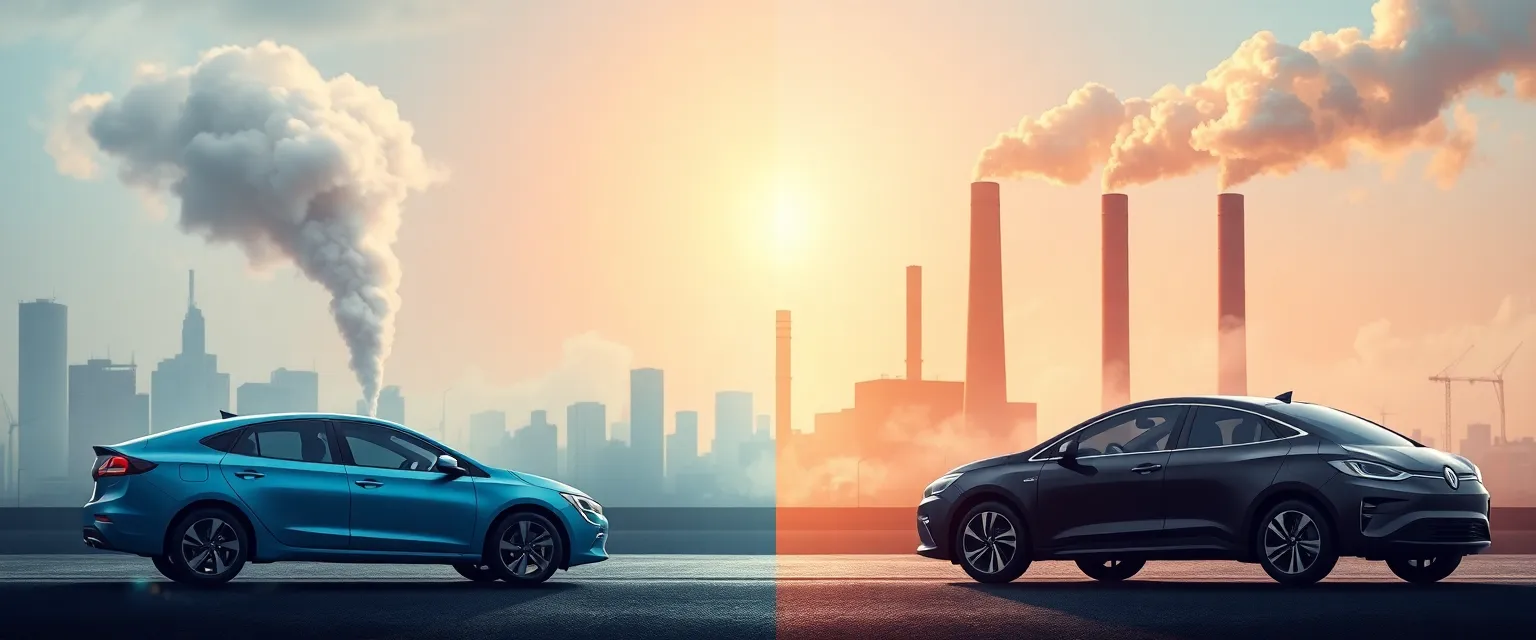

In [ ]:
import base64
import mimetypes

import requests

image_generation_workflow = ImageGenerationWorkflow()
image_result, cost = await image_generation_workflow.run(
    statement=statement,
    model="Latxa70B",
    image_model="flux",
)

# Show cost
print(f"💰 Step cost: {cost}")

# Display image from either base64 data URL or remote URL (in-memory only)


img_value = image_result.get("image_url")
if not img_value:
    print("No image returned.")
else:
    try:
        if isinstance(img_value, str) and img_value.startswith("data:"):
            # Already a data URL (e.g., data:image/png;base64,...) -> display directly
            display(HTML(f'<img src="{img_value}" style="max-width:100%;"/>'))
        elif isinstance(img_value, str):
            # Remote URL -> download in memory and embed as data URL
            resp = requests.get(img_value, timeout=60)
            resp.raise_for_status()
            mime = (
                resp.headers.get("Content-Type")
                or mimetypes.guess_type(img_value)[0]
                or "image/png"
            )
            b64 = base64.b64encode(resp.content).decode("ascii")
            data_url = f"data:{mime};base64,{b64}"
            display(HTML(f'<img src="{data_url}" style="max-width:100%;"/>'))
        else:
            print(f"Unexpected image value type: {type(img_value)}")
    except Exception as e:
        print(f"Failed to display image: {e}")